In [ ]:
from google.colab import drive

import zipfile
import os

import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import log_loss

In [ ]:
class DriveManager:
    def __init__(self, zip_path, extract_to):
        self.zip_path = zip_path
        self.extract_to = extract_to

    def mount_drive(self):
        drive.mount('/content/drive')

    def unzip_dataset(self):
        with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.extract_to)
        print(f"Unzipped to {self.extract_to}")


In [ ]:
drive_manager = DriveManager(
    zip_path='/content/drive/MyDrive/University/Bachelor/FinalProject/Voice_Emotions.zip',
    extract_to='/content/drive/MyDrive/University/Bachelor/FinalProject/voice_emotions'
)

drive_manager.mount_drive()
# drive_manager.unzip_dataset()


Mounted at /content/drive


In [ ]:
class AudioFeatureExtractor:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.features = []
        self.labels = []

    def extract_features(self):
      for folder in os.listdir(self.dataset_path):
        folder_path = os.path.join(self.dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue
        emotion = folder.split('_')[1].lower()
        gender = 'female' if folder.startswith('YAF') else 'male'

        for file in os.listdir(folder_path):
            if not file.endswith('.wav'):
                continue
            file_path = os.path.join(folder_path, file)
            y, sr = librosa.load(file_path, sr=None)

            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc.T, axis=0)
            delta = np.mean(librosa.feature.delta(mfcc).T, axis=0)
            delta2 = np.mean(librosa.feature.delta(mfcc, order=2).T, axis=0)

            chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
            contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
            mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)

            rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
            zcr = np.mean(librosa.feature.zero_crossing_rate(y))
            rmse = np.mean(librosa.feature.rms(y=y))

            combined = np.concatenate([
                mfcc_mean, delta, delta2,
                chroma, contrast, mel,
                [rolloff], [zcr], [rmse]
            ])

            self.features.append([*combined, emotion, gender])
            self.labels.append(emotion)

    def save_to_csv(self, csv_path):
        mfcc_cols = [f'mfcc{i+1}' for i in range(13)]
        delta_cols = [f'delta{i+1}' for i in range(13)]
        delta2_cols = [f'delta2_{i+1}' for i in range(13)]
        chroma_cols = [f'chroma{i+1}' for i in range(12)]
        contrast_cols = [f'contrast{i+1}' for i in range(7)]
        mel_cols = [f'mel{i+1}' for i in range(128)]
        other_cols = ['rolloff', 'zcr', 'rmse']
        columns = mfcc_cols + delta_cols + delta2_cols + chroma_cols + contrast_cols + mel_cols + other_cols + ['emotion', 'gender']
        df = pd.DataFrame(self.features, columns=columns)
        df.to_csv(csv_path, index=False)
        print(f"Features saved to {csv_path}")

    def get_features_and_labels(self):
        return np.array(self.features), np.array(self.labels)


In [ ]:
# extractor = AudioFeatureExtractor('/content/drive/MyDrive/University/Bachelor/FinalProject/voice_emotions')
# extractor.extract_features()
# extractor.save_to_csv('/content/drive/MyDrive/University/Bachelor/FinalProject/Datasets/voice_emotions.csv')

csv_path = '/content/drive/MyDrive/University/Bachelor/FinalProject/Datasets/voice_emotions.csv'


df = pd.read_csv(csv_path)
X = df.drop(columns=["emotion"]).values
y = df["emotion"].values

In [ ]:
class AudioDataLoader:
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)
        self.label_encoder = LabelEncoder()

    def encode_labels(self):
        self.data['label'] = self.label_encoder.fit_transform(self.data['emotion'])

    def get_splits(self, test_size=0.2):
        self.encode_labels()
        X = self.data.drop(columns=['emotion', 'gender', 'label']).values
        y = self.data['label'].values
        return train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    def get_label_encoder(self):
        return self.label_encoder


In [ ]:
loader = AudioDataLoader('/content/drive/MyDrive/University/Bachelor/FinalProject/Datasets/voice_emotions.csv')

# print(loader.data.head())
# print(loader.data.tail())
# print(loader.data.shape)
# print(loader.data.info())

X_train, X_test, y_train, y_test = loader.get_splits()
encoder = loader.get_label_encoder()


In [12]:
class AudioEmotionClassifier:
    def __init__(self, input_dim, n_classes, max_epochs=1000):
        self.model = MLPClassifier(
            hidden_layer_sizes=(1024, 512, ),
            max_iter=1,
            warm_start=True,
            random_state=42
        )
        self.max_epochs = max_epochs
        self.n_classes = n_classes
        self.input_dim = input_dim
        self.label_encoder = LabelEncoder()
        self.train_losses = []
        self.test_losses = []
        self.train_accuracies = []
        self.test_accuracies = []

    def train(self, X_train, y_train, X_test, y_test):
        y_train_enc = self.label_encoder.fit_transform(y_train)
        y_test_enc = self.label_encoder.transform(y_test)

        for epoch in range(1, self.max_epochs + 1):
            self.model.fit(X_train, y_train_enc)

            # Predict on training and test data
            train_preds = self.model.predict(X_train)
            test_preds = self.model.predict(X_test)

            # Compute accuracy
            train_acc = accuracy_score(y_train_enc, train_preds)
            test_acc = accuracy_score(y_test_enc, test_preds)

            # Compute loss
            train_probs = self.model.predict_proba(X_train)
            test_probs = self.model.predict_proba(X_test)

            train_loss = log_loss(y_train_enc, train_probs)
            test_loss = log_loss(y_test_enc, test_probs)

            # Save metrics
            self.train_accuracies.append(train_acc)
            self.test_accuracies.append(test_acc)
            self.train_losses.append(train_loss)
            self.test_losses.append(test_loss)

        print(f"✅ Epoch {epoch}/{self.max_epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

    def plot_metrics(self):
        epochs = range(1, self.max_epochs + 1)

        plt.figure(figsize=(14, 5))

        # Accuracy plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_accuracies, label='Train Accuracy')
        plt.plot(epochs, self.test_accuracies, label='Test Accuracy')
        plt.title("Accuracy over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        # Loss plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.train_losses, label='Train Loss')
        plt.plot(epochs, self.test_losses, label='Test Loss')
        plt.title("Loss over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.tight_layout()
        plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

✅ Epoch 403/403 - Train Acc: 0.9879, Test Acc: 0.9821, Train Loss: 0.0521, Test Loss: 0.1207


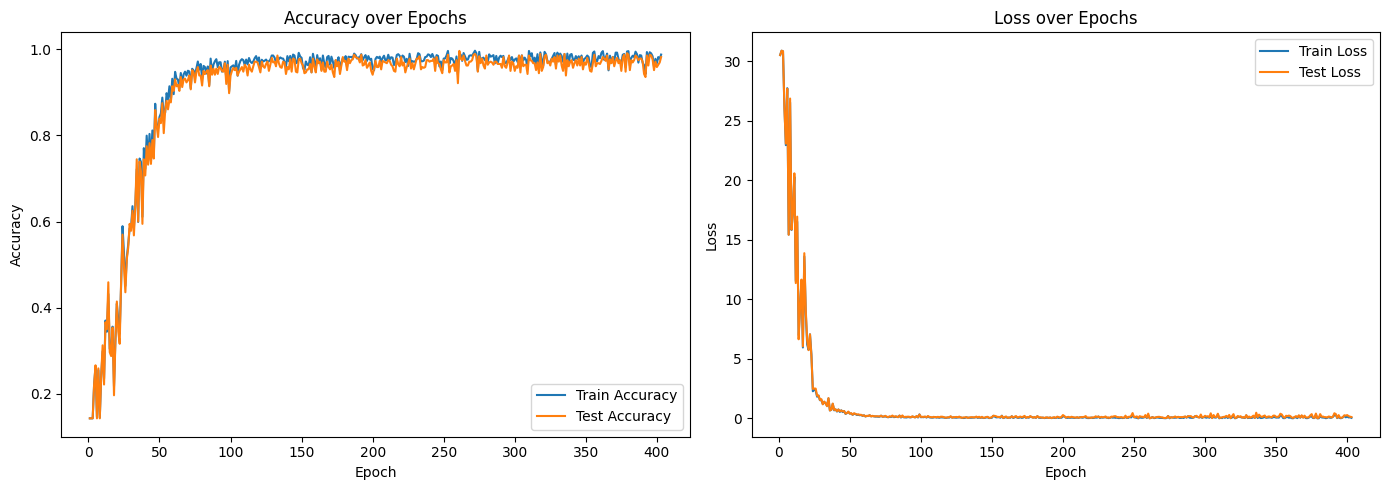

In [27]:
model = AudioEmotionClassifier(input_dim=X_train.shape[1], n_classes=len(np.unique(y)), max_epochs=337)
model.train(X_train, y_train, X_test, y_test)
model.plot_metrics()

In [25]:
class ModelPersistence:
    def __init__(self, model_dir):
        self.model_dir = model_dir
        os.makedirs(self.model_dir, exist_ok=True)
        self.model_path = os.path.join(self.model_dir, 'audio_emotion_model.pkl')
        self.encoder_path = os.path.join(self.model_dir, 'label_encoder.pkl')

    def save(self, model, label_encoder):
        joblib.dump(model, self.model_path)
        joblib.dump(label_encoder, self.encoder_path)
        print(f"✅ Model saved to: {self.model_path}")
        print(f"✅ Label encoder saved to: {self.encoder_path}")

    def load(self):
        if not os.path.exists(self.model_path) or not os.path.exists(self.encoder_path):
            raise FileNotFoundError("Model or encoder file not found. Make sure they are saved correctly.")

        model = joblib.load(self.model_path)
        label_encoder = joblib.load(self.encoder_path)
        print(f"✅ Model and encoder loaded from {self.model_dir}")
        return model, label_encoder


In [26]:
drive.mount('/content/drive')

model_saver = ModelPersistence('/content/drive/MyDrive/University/Bachelor/FinalProject/Models/Voice')
model_saver.save(model.model, model.label_encoder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to: /content/drive/MyDrive/University/Bachelor/FinalProject/Models/Voice/audio_emotion_model.pkl
✅ Label encoder saved to: /content/drive/MyDrive/University/Bachelor/FinalProject/Models/Voice/label_encoder.pkl
